### Conjugate Gradient Algorithm:

It tries to solve the equation:
$$
Ax = b
$$
Solution of this equation is equivalent to maximizing:
$$
\underset{x}{\mathrm{maximize}} \quad f(\mathbf{x}) = \frac{1}{2} x^T A x - b^T x
$$
Since:
$$
\nabla f(\mathbf{x}) = Ax - b = \mathbf{0}
$$


In [35]:
import numpy as np
import matplotlib.pyplot as plt

def objective(x):
    return (0.5 * x.T @ A @ x) - (b.T @ x)

def conjugate_gradient(A, b, x0, T = 25):
    x = x0.copy()
    r = b - (A@x)
    d = r.copy()
    history = []
    for t in range(T):
        alpha = r.T @ r
        alpha = alpha/((d.T@(A)@(d))+1e-16)
        x = x + (alpha*d)
        r1 = r - (alpha*(A@d))
        beta = r1.T @ r1
        beta = beta / (r.T @ r)
        d = r1 + (beta * d)
        r = r1
        history.append(objective(x))
    return x, history

Solution:
[0.09090909 0.63636364]


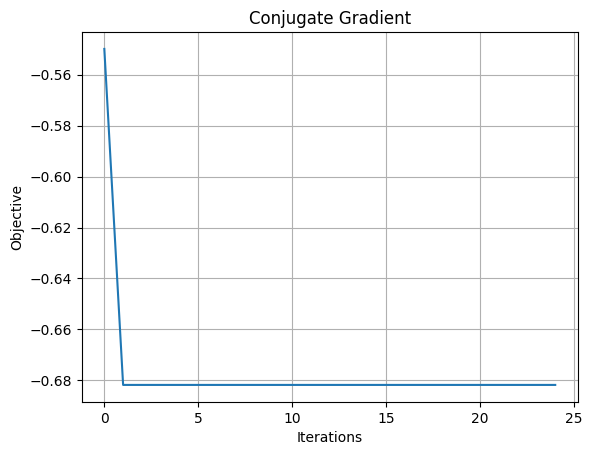

In [36]:
A = np.array([
    [4, 1],
    [1, 3]
], dtype=float)
b = np.array([1, 2], dtype=float)
x0 = np.array([2, 1], dtype=float)

sol, history = conjugate_gradient(A, b, x0)

print("Solution:")
print(sol)

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Objective")
plt.title("Conjugate Gradient")
plt.grid(True)
plt.show()